In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read image in grayscale
img = cv2.imread("moon.jpg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Could not read image: moon.jpg")

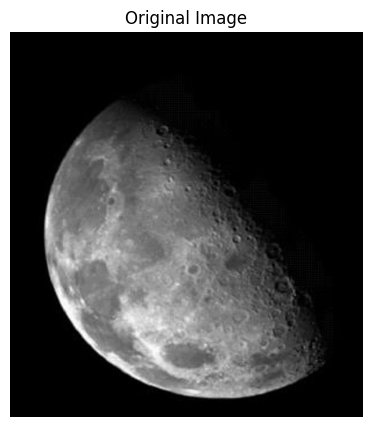

In [3]:
# Display original image
plt.figure(figsize=(5,5))
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [4]:
# Manual Laplacian kernel
manual_kernel = np.array([
    [0,  1,  0],
    [1, -4,  1],
    [0,  1,  0]
], dtype=np.float32)

laplacian_manual = cv2.filter2D(img, cv2.CV_64F, manual_kernel)
laplacian_abs = cv2.convertScaleAbs(laplacian_manual)

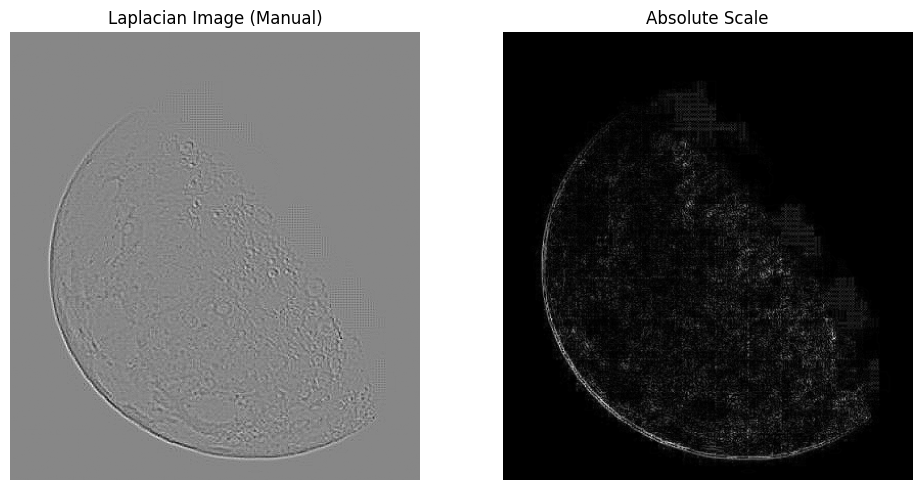

In [5]:
# Show Laplacian result
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(laplacian_manual, cmap="gray")
plt.title("Laplacian Image (Manual)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(laplacian_abs, cmap="gray")
plt.title("Absolute Scale")
plt.axis("off")

plt.tight_layout()
plt.show()

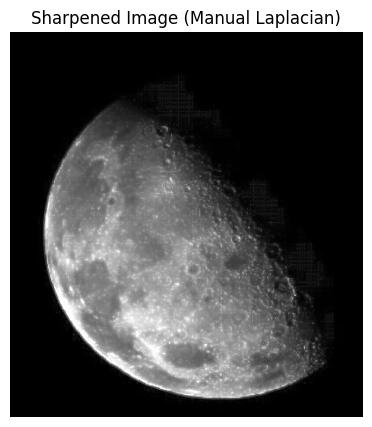

In [6]:
# Sharpen image by adding Laplacian to original image
sharpened_manual = cv2.add(img, laplacian_abs)

plt.figure(figsize=(5,5))
plt.imshow(sharpened_manual, cmap="gray")
plt.title("Sharpened Image (Manual Laplacian)")
plt.axis("off")
plt.show()

In [7]:
# Apply Gaussian blur before OpenCV Laplacian
blurred = cv2.GaussianBlur(img, (3, 3), 0)
laplacian_cv = cv2.Laplacian(blurred, cv2.CV_64F)
laplacian_cv_abs = cv2.convertScaleAbs(laplacian_cv)

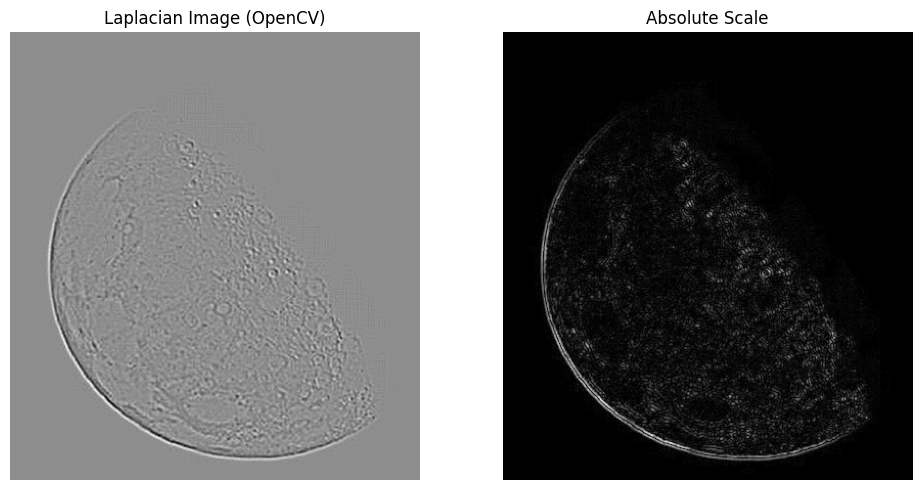

In [8]:
# Display OpenCV Laplacian
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(laplacian_cv, cmap="gray")
plt.title("Laplacian Image (OpenCV)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(laplacian_cv_abs, cmap="gray")
plt.title("Absolute Scale")
plt.axis("off")

plt.tight_layout()
plt.show()

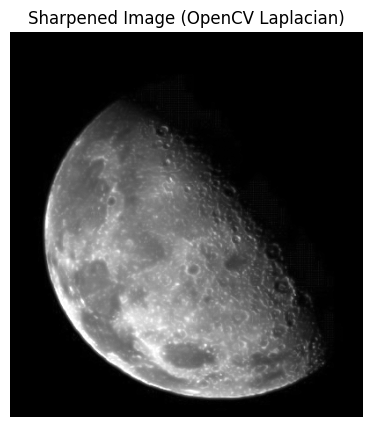

In [9]:
# Final sharpened image using OpenCV Laplacian
sharpened_cv = cv2.add(img, laplacian_cv_abs)

plt.figure(figsize=(5,5))
plt.imshow(sharpened_cv, cmap="gray")
plt.title("Sharpened Image (OpenCV Laplacian)")
plt.axis("off")
plt.show()